# Are you happy if you listen to k-pop?
This project is made to generate charts about [Music & Mental Health Survey Results](https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results) from Kaggle

# Requirements

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('mxmh_survey_results.csv')

# Mapping fréquences
mapping = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
freq_cols = [col for col in df.columns if 'Frequency' in col]
for col in freq_cols:
    df[col] = df[col].map(mapping)

# Score santé mentale global
mental = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
df['Mental Health'] = df[mental].sum(axis=1)

# Groupes d'âge
df['Age_group'] = pd.cut(df['Age'],
                         bins=[10, 18, 25, 35, 50, 100],
                         labels=['10-18', '18-25', '25-35', '35-50', '50+'])

df['Hours_group'] = pd.cut(df['Hours per day'],
                           bins=[0, 1, 3, 5, 8, 24],
                           labels=['<1h', '1-3h', '3-5h', '5-8h', '8h+'])

# Musicien ou non
df['Musician'] = ((df['Instrumentalist'] == 'Yes') | (df['Composer'] == 'Yes'))

# Palette commune
YELLOWS = ['#ffffe6', '#ffffcc', '#ffffb3', '#ffff99', '#ffff80', '#ffff66', '#ffff4d', '#ffff33']
BLUES   = ['#ebebf9', '#d8d8f3', '#c4c4ed', '#b0b0e8', '#9d9de2', '#8989dc', '#7676d6', '#6262d1']
YELLOW_MAIN = '#ffff99'
BLUE_MAIN   = '#b0b0e8'

def style_ax(ax, fig):
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

age_stats = df.groupby('Age_group', observed=True)['Mental Health'].mean().reset_index()
age_stats.columns = ['Age Group', 'Mean Mental Health']
df['Age Group'] = df['Age_group']

# Import data

In [12]:
df = pd.read_csv('mxmh_survey_results.csv')

display(df.head())
display(df.info())
display(df.describe())

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

None

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [13]:
# Changer les fréquences d'écoutes en int
mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Very frequently': 3
}
columns = ['Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]']

for column in columns:
    df[column] = df[column].map(mapping)
df[columns].info()
df[columns].head()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Frequency [Classical]         736 non-null    int64
 1   Frequency [Country]           736 non-null    int64
 2   Frequency [EDM]               736 non-null    int64
 3   Frequency [Folk]              736 non-null    int64
 4   Frequency [Gospel]            736 non-null    int64
 5   Frequency [Hip hop]           736 non-null    int64
 6   Frequency [Jazz]              736 non-null    int64
 7   Frequency [K pop]             736 non-null    int64
 8   Frequency [Latin]             736 non-null    int64
 9   Frequency [Lofi]              736 non-null    int64
 10  Frequency [Metal]             736 non-null    int64
 11  Frequency [Pop]               736 non-null    int64
 12  Frequency [R&B]               736 non-null    int64
 13  Frequency [Rap]               736 non-null    

,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music]
0,1,0,1,0,0,2,0,3,3,1,0,3,2,3,0,2
1,2,0,0,1,2,1,3,1,2,1,0,2,2,1,3,1
2,0,0,3,0,0,1,1,3,0,2,2,1,0,1,1,3
3,2,0,0,1,2,0,3,2,3,2,0,2,2,0,0,0
4,0,0,1,0,1,3,0,3,2,2,0,2,3,3,0,1


In [14]:
# Création de la colonne Mental Health (somme des 4 scores)
df['Mental Health'] = df['Anxiety'] + df['Depression'] + df['Insomnia'] + df['OCD']

print(df[['Anxiety', 'Depression', 'Insomnia', 'OCD', 'Mental Health']].head(8))

#df.to_csv('mxmh_survey_results_updated.csv', index=False)
display(df.head())
display(df.info())

   Anxiety  Depression  Insomnia  OCD  Mental Health
0      3.0         0.0       1.0  0.0            4.0
1      7.0         2.0       2.0  1.0           12.0
2      7.0         7.0      10.0  2.0           26.0
3      9.0         7.0       3.0  3.0           22.0
4      7.0         2.0       5.0  9.0           23.0
5      8.0         8.0       7.0  7.0           30.0
6      4.0         8.0       6.0  0.0           18.0
7      5.0         3.0       5.0  3.0           16.0


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions,Mental Health
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,3,0,2,3.0,0.0,1.0,0.0,NaN,I understand.,4.0
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,1,3,1,7.0,2.0,2.0,1.0,NaN,I understand.,12.0
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,1,1,3,7.0,7.0,10.0,2.0,No effect,I understand.,26.0
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,0,0,0,9.0,7.0,3.0,3.0,Improve,I understand.,22.0
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,3,0,1,7.0,2.0,5.0,9.0,Improve,I understand.,23.0


<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    int64  
 12  Frequency [Country]           736 non-null    int64  
 13  Frequency [EDM] 

None

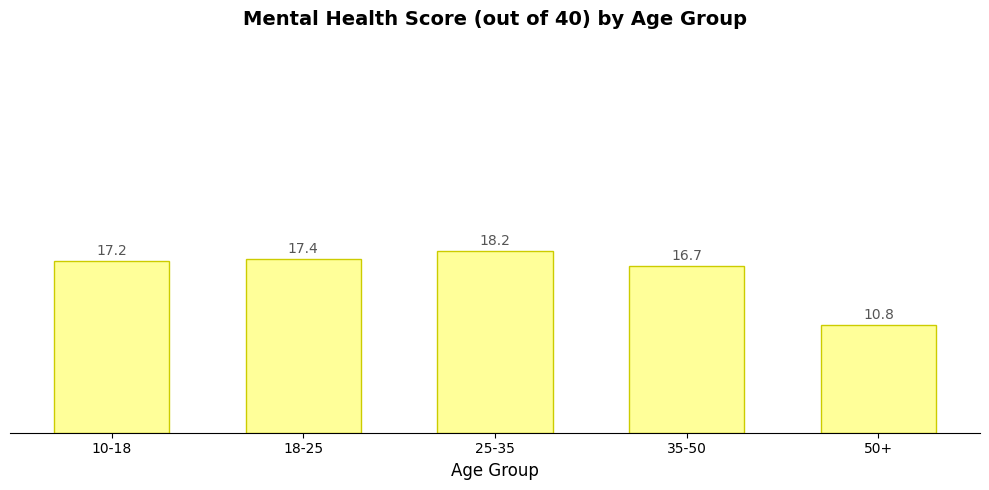

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

bars = ax.bar(age_stats['Age Group'], age_stats['Mean Mental Health'],
              color=YELLOWS[3], edgecolor='#cccc00', width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color='#555')
    
ax.yaxis.set_visible(False)   # retire l'axe Y
ax.grid(False)                # retire la grille
ax.spines[['left']].set_visible(False)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Average Mental Health Score (0–40)', fontsize=12)
ax.set_title('Mental Health Score (out of 40) by Age Group', fontsize=14, fontweight='bold')
ax.set_ylim(0, 40)

plt.tight_layout()
plt.show()

KeyError: 'Age_group'

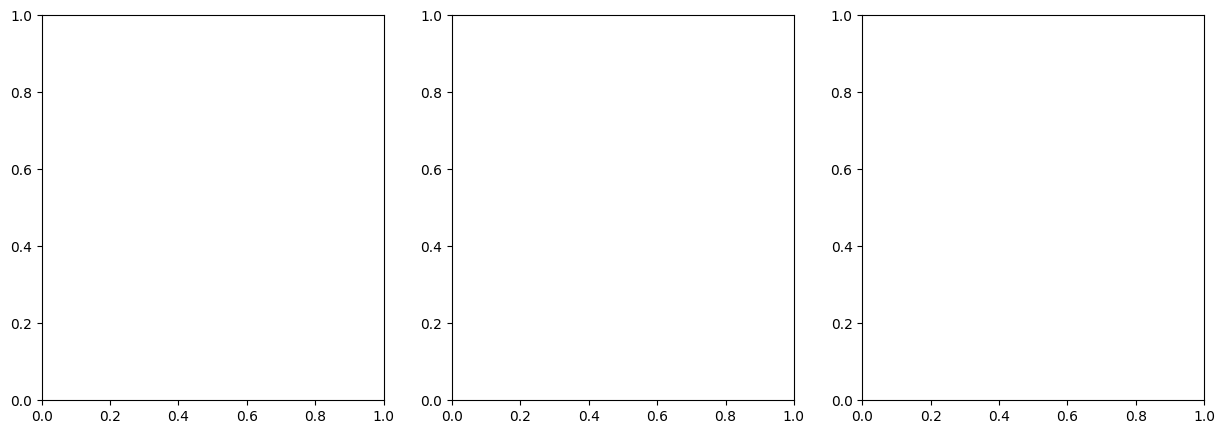

In [16]:
tranches = ['18-25', '25-35', '35-50']
colonnes = ['Depression', 'Insomnia', 'OCD', 'Anxiety']
couleurs = [YELLOWS[2], YELLOWS[4], BLUES[2], BLUES[4]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')

for ax, tranche in zip(axes, tranches):
    groupe = df[df['Age_group'] == tranche][colonnes].mean()

    wedges, texts, autotexts = ax.pie(
        groupe,
        labels=colonnes,
        colors=couleurs,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    ax.set_title(f'{tranche} ans', fontsize=13, fontweight='bold')

plt.suptitle("Contribution des troubles à la santé mentale par tranche d'âge", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

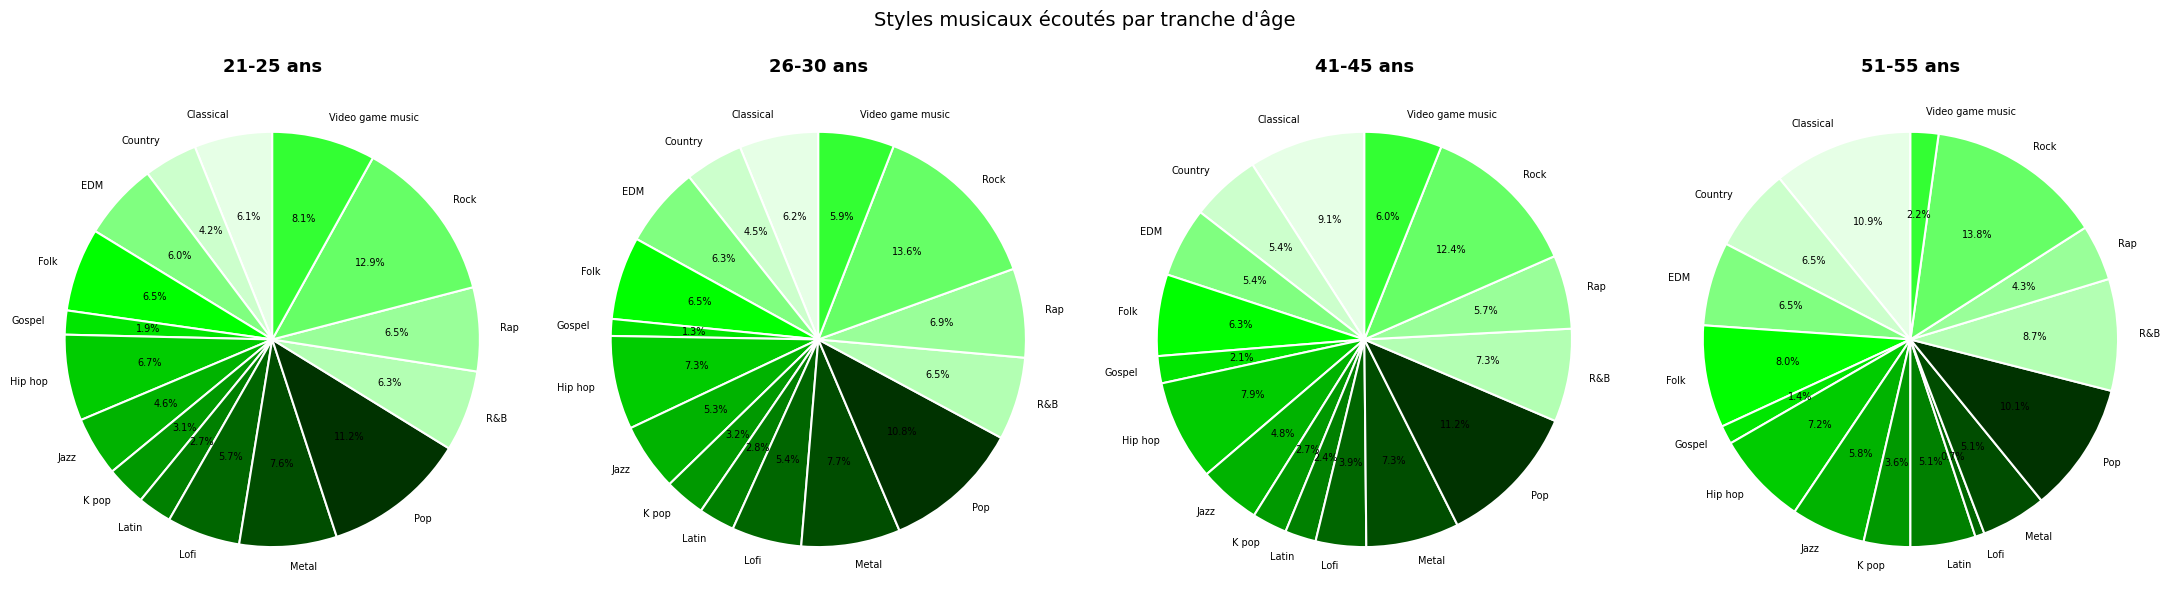

In [ ]:
tranches = ['21-25', '26-30', '41-45', '51-55']
freq_cols = [col for col in df.columns if 'Frequency' in col]
genre_labels = [col.replace('Frequency [', '').replace(']', '') for col in freq_cols]

freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Frequently': 3, 'Very frequently': 4}
for col in freq_cols:
    df[col] = df[col].map(freq_map)

couleurs = ['#e6ffe6', '#ccffcc', '#80ff80', '#00ff00', '#00e600', '#00cc00', '#00b300',
            '#009900', '#008000', '#006600', '#004d00', '#003300', '#b3ffb3', '#99ff99',
            '#66ff66', '#33ff33']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor('white')

for ax, tranche in zip(axes, tranches):
    groupe = df[df['Age Group'] == tranche][freq_cols].mean()
    groupe.index = genre_labels

    ax.pie(
        groupe,
        labels=genre_labels,
        colors=couleurs[:len(freq_cols)],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 7}
    )
    ax.set_title(f'{tranche} ans', fontsize=13, fontweight='bold')

plt.suptitle("Styles musicaux écoutés par tranche d'âge", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

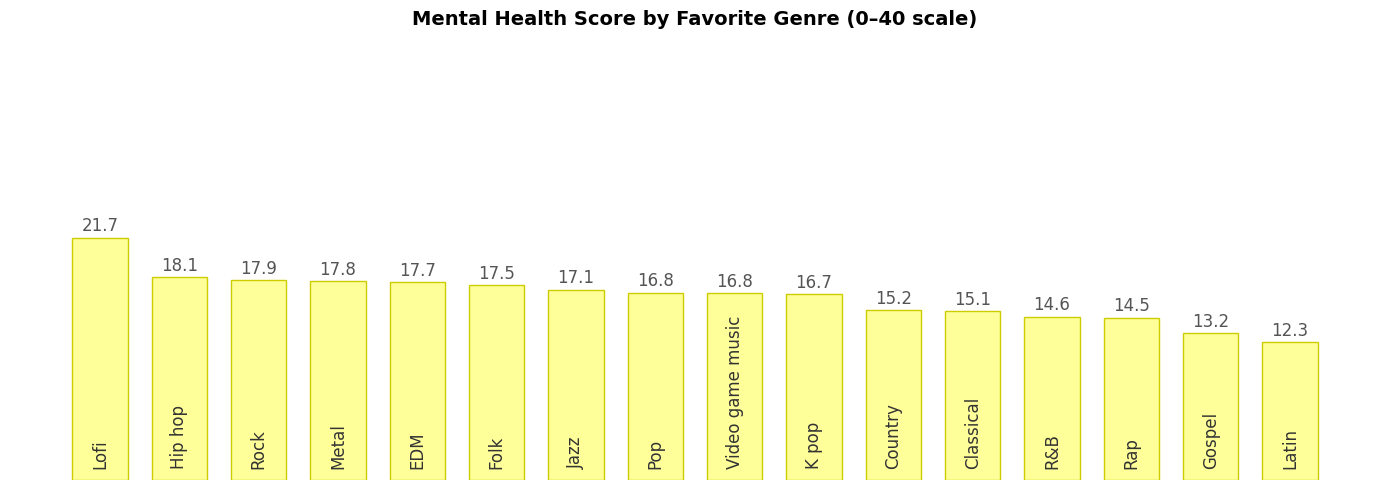

In [37]:
genre_stats = df.groupby('Fav genre')['Mental Health'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
style_ax(ax, fig)

bars = ax.bar(genre_stats.index, genre_stats.values,
              color=YELLOWS[3], edgecolor='#cccc00', width=0.7)

# Valeurs au-dessus des barres
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=12, color='#555')

for bar, label in zip(bars, genre_stats.index):
    ax.text(bar.get_x() + bar.get_width() / 2,
            1,  # position proche du bas
            label,
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=12,
            color='#333')

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

ax.set_title('Mental Health Score by Favorite Genre (0–40 scale)',
             fontsize=14, fontweight='bold')

ax.set_ylim(0, 40)

plt.tight_layout()
plt.show()

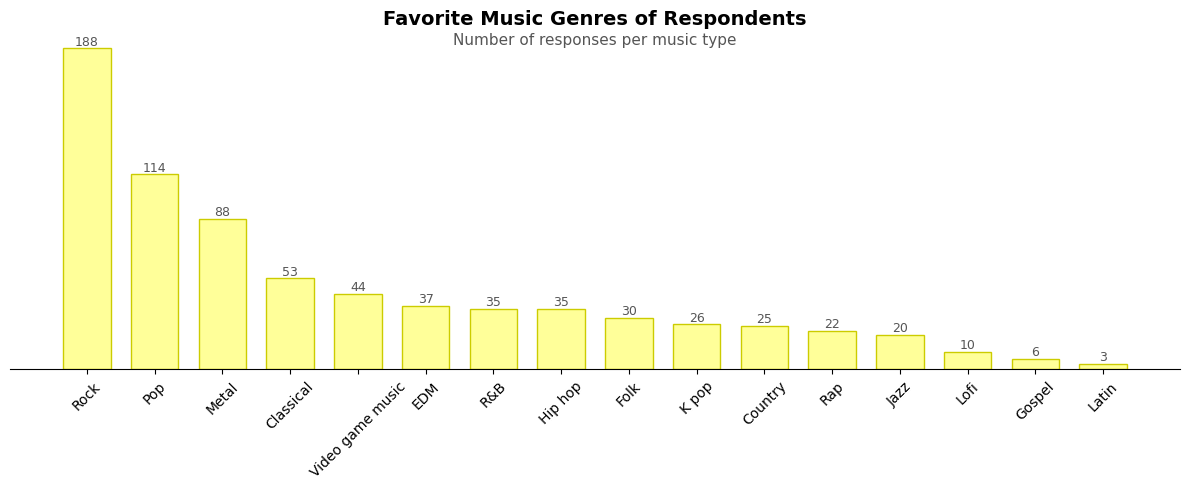

In [54]:
genre_counts = df['Fav genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

fig, ax = plt.subplots(figsize=(12, 5))
style_ax(ax, fig)

bars = ax.bar(genre_counts['Genre'], genre_counts['Count'],
              color=YELLOWS[3], edgecolor='#cccc00', width=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, color='#555')


ax.yaxis.set_visible(False)   # retire l'axe Y
ax.xaxis.label.set_visible(False)
ax.grid(False)                # retire la grille
ax.spines[['left']].set_visible(False)

fig.text(0.5, 0.90, 'Number of responses per music type', ha='center', fontsize=11, color='#555')

ax.set_title('Favorite Music Genres of Respondents', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

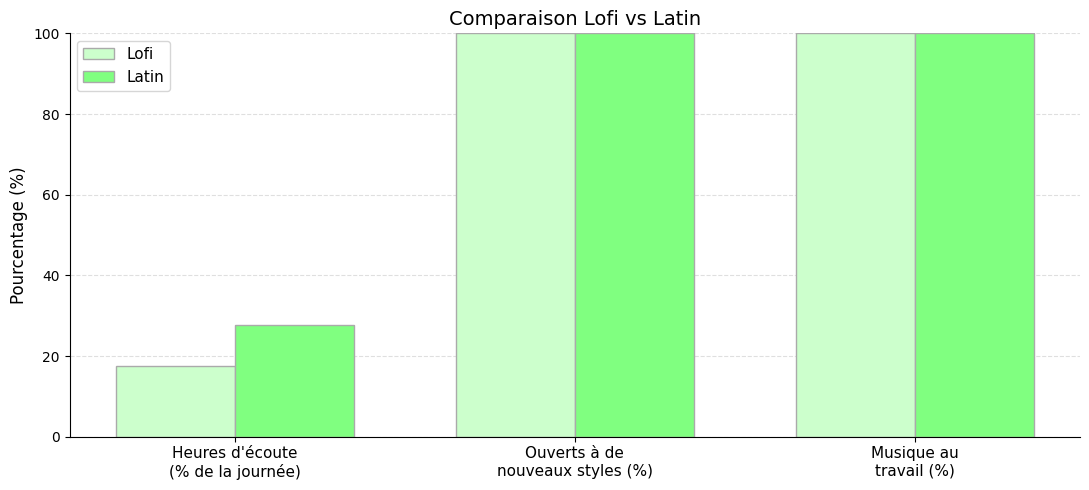

In [ ]:
df['Exploratory_num'] = (df['Exploratory'] == 'Yes').astype(int)
df['While working_num'] = (df['While working'] == 'Yes').astype(int)
df['Hours pct'] = df['Hours per day'] / 24 * 100

lofi = df[df['Fav genre'] == 'Lofi']
latin = df[df['Fav genre'] == 'Latin']

metrics = {
    "Heures d'écoute\n(% de la journée)": (lofi['Hours pct'].mean(), latin['Hours pct'].mean()),
    "Ouverts à de\nnouveaux styles (%)": (lofi['Exploratory_num'].mean() * 100, latin['Exploratory_num'].mean() * 100),
    "Musique au\ntravail (%)": (lofi['While working_num'].mean() * 100, latin['While working_num'].mean() * 100),
}

labels = list(metrics.keys())
lofi_vals = [v[0] for v in metrics.values()]
latin_vals = [v[1] for v in metrics.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

bars1 = ax.bar(x - width/2, lofi_vals, width, label='Lofi', color='#ccffcc', edgecolor='#aaaaaa')
bars2 = ax.bar(x + width/2, latin_vals, width, label='Latin', color='#80ff80', edgecolor='#aaaaaa')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Comparaison Lofi vs Latin', fontsize=14)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

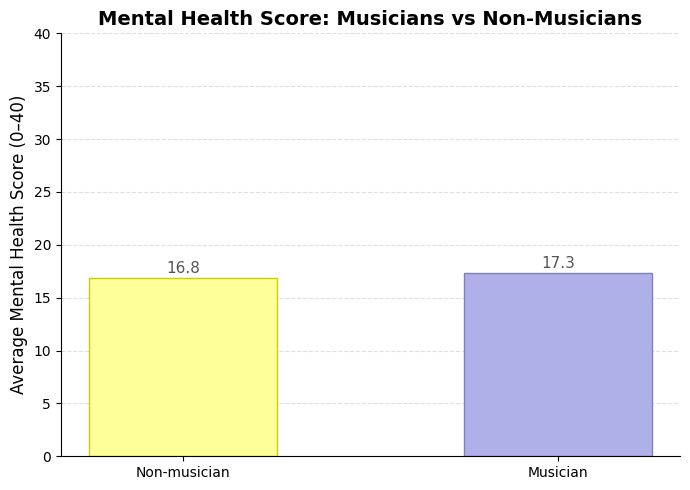

In [ ]:
musician_stats = df.groupby('Musician')['Mental Health'].mean()
musician_stats.index = ['Non-musician', 'Musician']

fig, ax = plt.subplots(figsize=(7, 5))
style_ax(ax, fig)

bars = ax.bar(musician_stats.index, musician_stats.values,
              color=[YELLOWS[3], BLUES[3]], edgecolor=['#cccc00', '#8080c0'], width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=11, color='#555')

ax.set_ylabel('Average Mental Health Score (0–40)', fontsize=12)
ax.set_title('Mental Health Score: Musicians vs Non-Musicians', fontsize=14, fontweight='bold')
ax.set_ylim(0, 40)

plt.tight_layout()
plt.show()

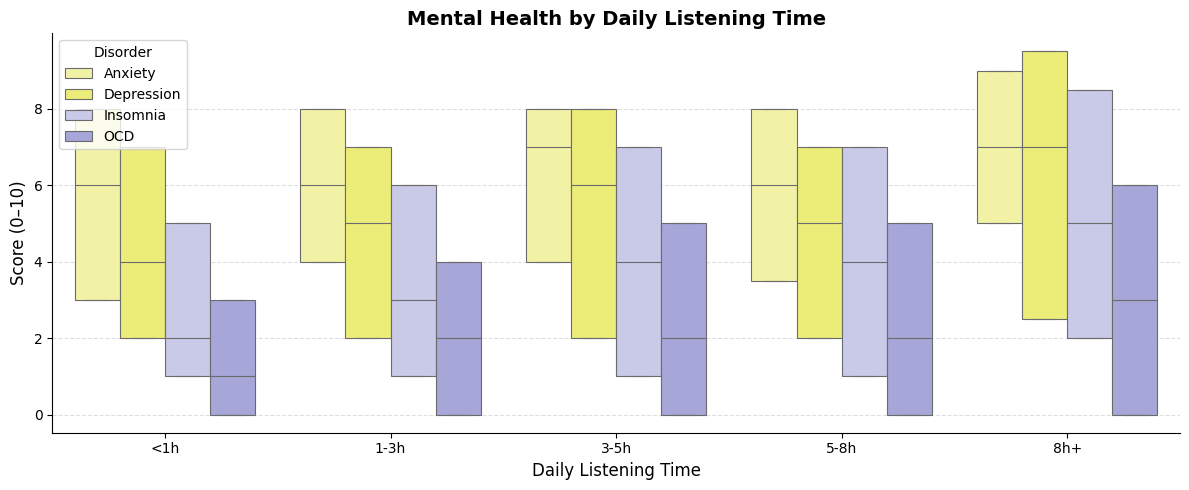

In [62]:
df["Hours_group"] = pd.cut(
    df["Hours per day"],
    bins=[0, 1, 3, 5, 8, 24],
    labels=["<1h", "1-3h", "3-5h", "5-8h", "8h+"]
)

df_long_hours = df.melt(
    id_vars=["Hours_group"],
    value_vars=mental,
    var_name="Disorder",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(12, 5))
style_ax(ax, fig)

palette = {
    'Anxiety': YELLOWS[3],
    'Depression': YELLOWS[5],
    'Insomnia': BLUES[2],
    'OCD': BLUES[4],
}

sns.boxplot(
    data=df_long_hours,
    x="Hours_group",
    y="Score",
    hue="Disorder",
    palette=palette,
    ax=ax,
    linewidth=0.8,
    fliersize=2,
    whis=0,
    showfliers=False
)

ax.set_xlabel('Daily Listening Time', fontsize=12)
ax.set_ylabel('Score (0–10)', fontsize=12)
ax.set_title('Mental Health by Daily Listening Time', fontsize=14, fontweight='bold')
ax.legend(title='Disorder', fontsize=10, loc='upper left', bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.show()

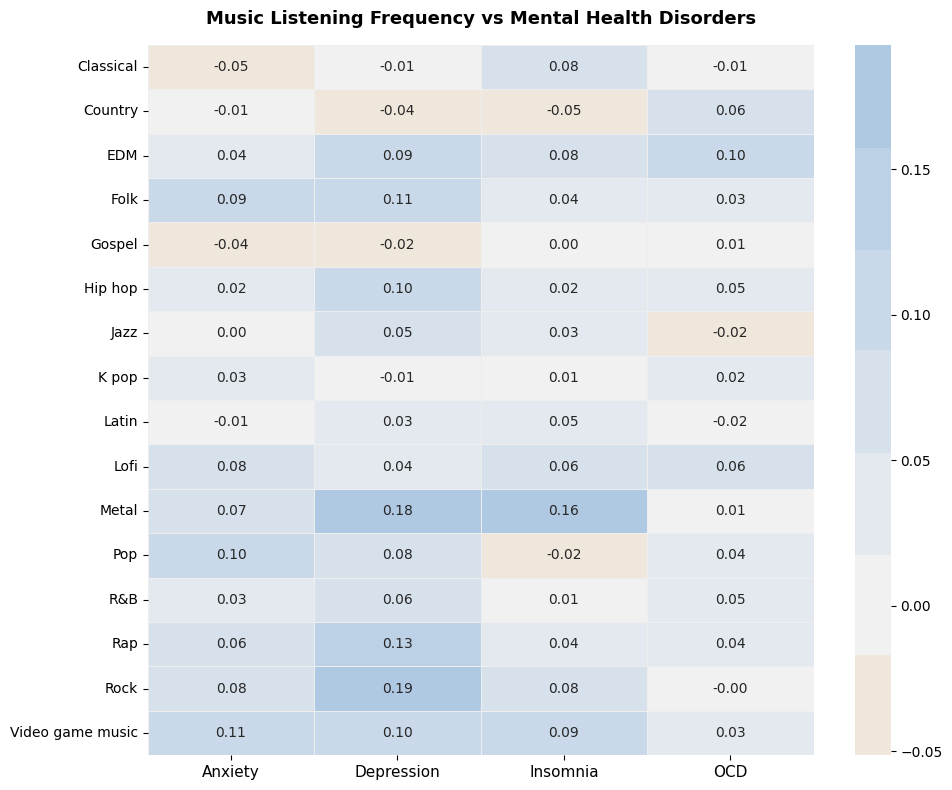

In [ ]:
corr = df[freq_cols + mental].corr()
corr_subset = corr.loc[freq_cols, mental]
genre_labels = [col.replace('Frequency [', '').replace(']', '') for col in freq_cols]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

sns.heatmap(corr_subset, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(55, 240, s=50, l=80, n=11, center='light'),
            center=0, linewidths=0.5, linecolor='#eee',
            xticklabels=mental,
            yticklabels=genre_labels,
            ax=ax)

ax.set_title('Music Listening Frequency vs Mental Health Disorders',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.show()

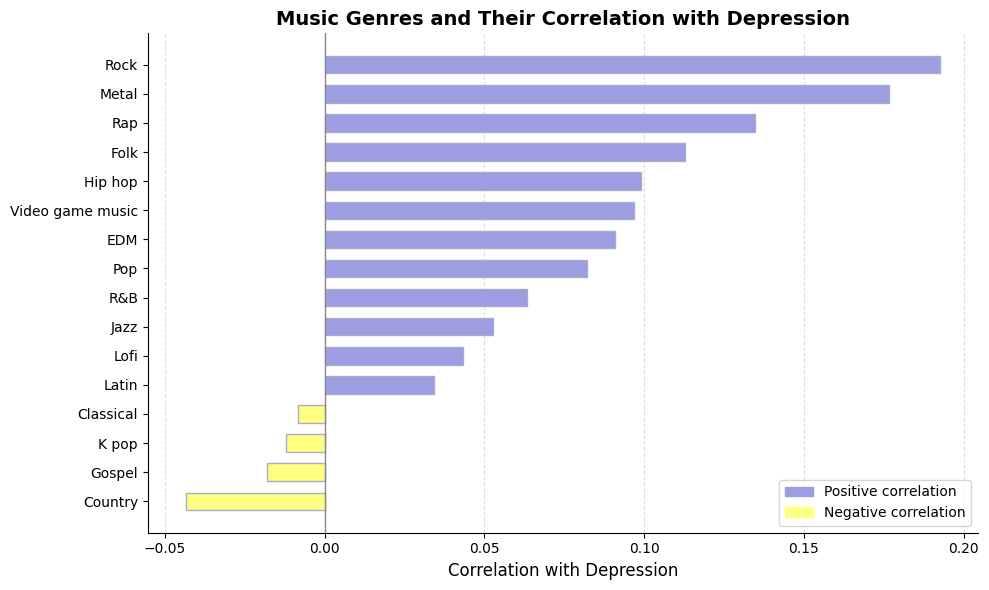

In [ ]:
corr = df[freq_cols + mental].corr()
corr_dep = corr.loc[freq_cols, 'Depression'].sort_values()
genre_labels_sorted = [col.replace('Frequency [', '').replace(']', '') for col in corr_dep.index]

colors = [BLUES[4] if v >= 0 else YELLOWS[4] for v in corr_dep.values]

fig, ax = plt.subplots(figsize=(10, 6))
style_ax(ax, fig)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.grid(False)

ax.barh(genre_labels_sorted, corr_dep.values, color=colors, edgecolor='#aaaacc', height=0.6)
ax.axvline(0, color='#888', linewidth=1)

ax.set_xlabel('Correlation with Depression', fontsize=12)
ax.set_title('Music Genres and Their Correlation with Depression', fontsize=14, fontweight='bold')

import matplotlib.patches as mpatches
patch_pos = mpatches.Patch(color=BLUES[4], label='Positive correlation')
patch_neg = mpatches.Patch(color=YELLOWS[4], label='Negative correlation')
ax.legend(handles=[patch_pos, patch_neg], fontsize=10)

plt.tight_layout()
plt.show()

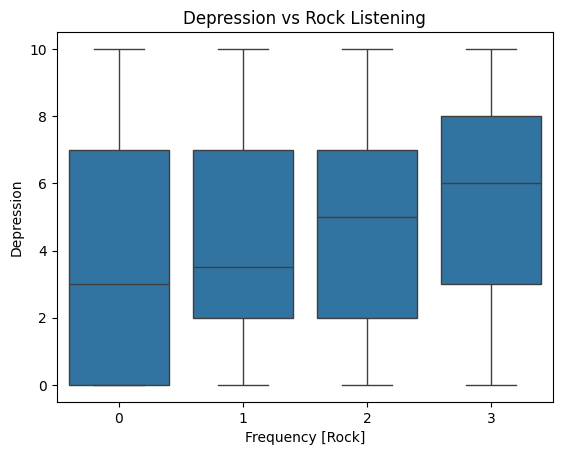

In [ ]:
sns.boxplot(x="Frequency [Rock]", y="Depression", data=df)
plt.title("Depression vs Rock Listening")
plt.show()

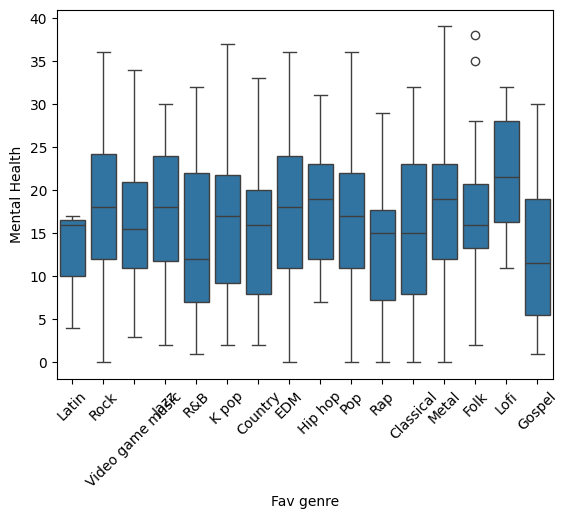

In [ ]:
sns.boxplot(
    x="Fav genre",
    y="Mental Health",
    data=df
)
plt.xticks(rotation=45)
plt.show()

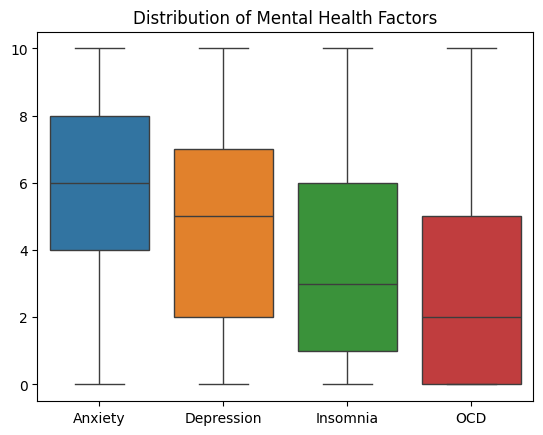

In [ ]:
import seaborn as sns

sns.boxplot(data=df[mental])
plt.title("Distribution of Mental Health Factors")
plt.show()

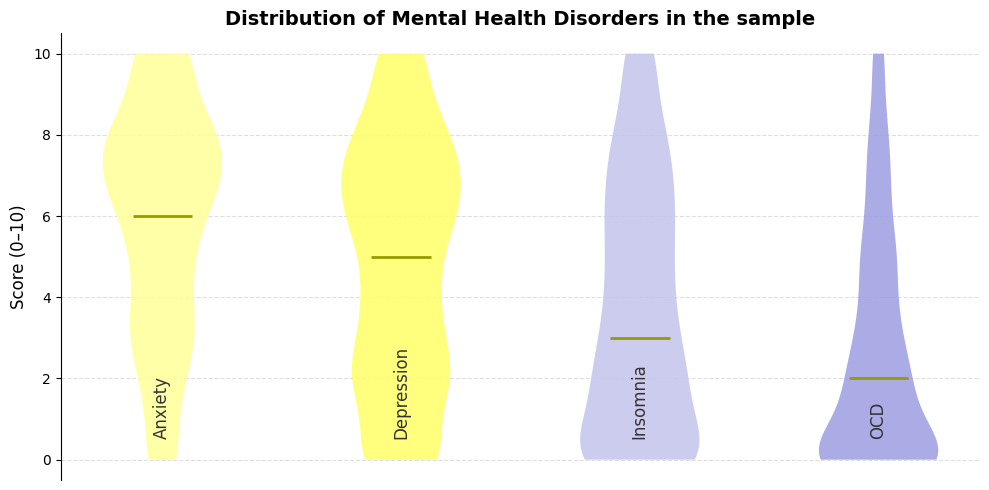

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

palette = {
    'Anxiety': YELLOWS[3],
    'Depression': YELLOWS[5],
    'Insomnia': BLUES[2],
    'OCD': BLUES[4],
}

parts = ax.violinplot([df[m].dropna() for m in mental],
                      positions=range(len(mental)),
                      showmedians=True, showextrema=False)

for pc, m in zip(parts['bodies'], mental):
    pc.set_facecolor(palette[m])
    pc.set_alpha(0.85)

parts['cmedians'].set_color('#999900')
parts['cmedians'].set_linewidth(2)

ax.spines[['bottom']].set_visible(False)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Score (0–10)', fontsize=12)

for i, m in enumerate(mental):
    ax.text(i, 0.5, m, rotation=90, ha='center', va='bottom', fontsize=12, color='#333')

ax.set_title('Distribution of Mental Health Disorders in the sample', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

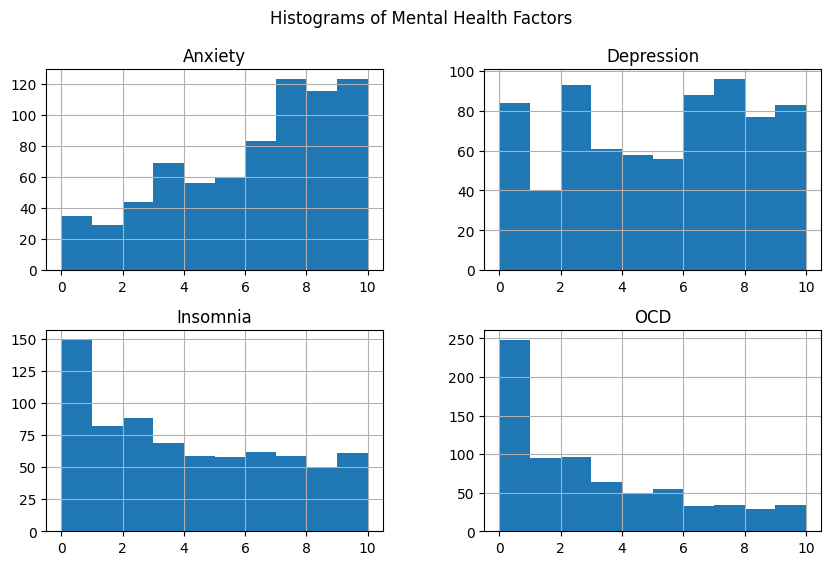

In [ ]:
df[mental].hist(figsize=(10, 6), bins=10)
plt.suptitle("Histograms of Mental Health Factors")
plt.show()

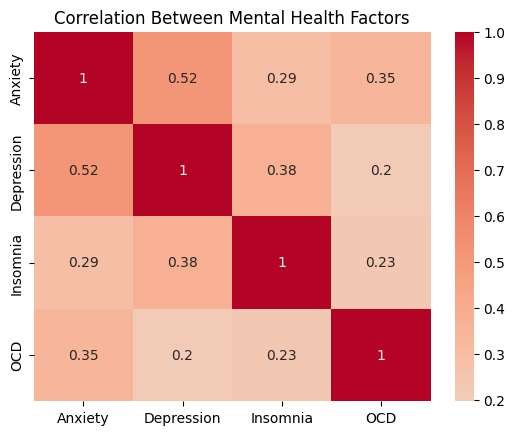

In [ ]:
corr = df[mental].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Mental Health Factors")
plt.show()

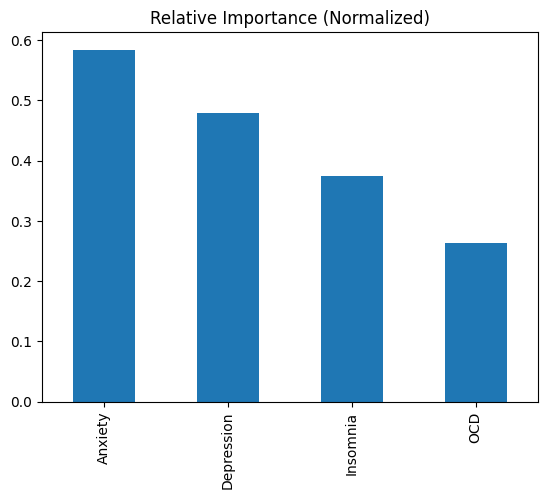

In [ ]:
(df[mental] / df[mental].max()).mean().plot(kind="bar")
plt.title("Relative Importance (Normalized)")
plt.show()

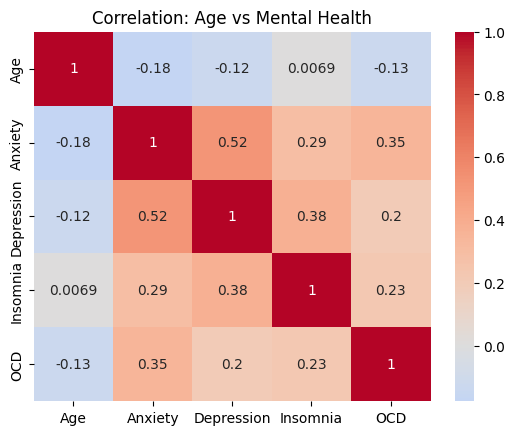

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[["Age", "Anxiety", "Depression", "Insomnia", "OCD"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Age vs Mental Health")
plt.show()

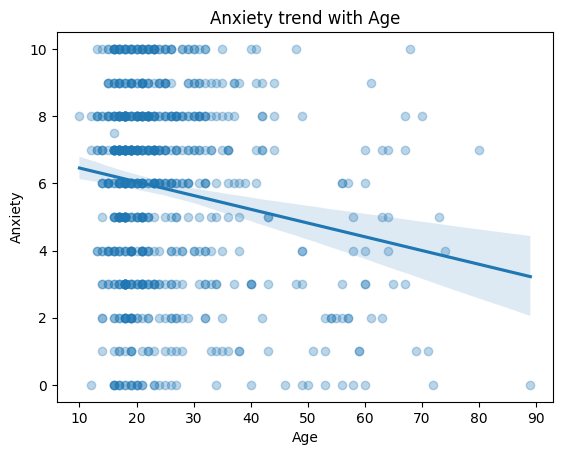

In [ ]:
sns.regplot(x="Age", y="Anxiety", data=df, scatter_kws={"alpha":0.3})
plt.title("Anxiety trend with Age")
plt.show()

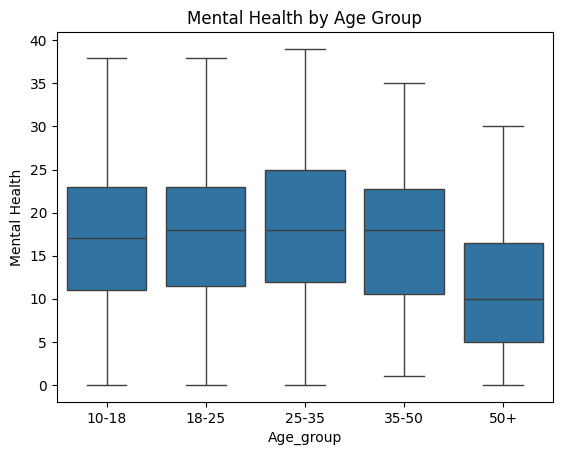

In [ ]:
df["Age_group"] = pd.cut(df["Age"],
                         bins=[10, 18, 25, 35, 50, 100],
                         labels=["10-18", "18-25", "25-35", "35-50", "50+"])

sns.boxplot(x="Age_group", y="Mental Health", data=df)
plt.title("Mental Health by Age Group")
plt.show()

In [ ]:
import pandas as pd

mental = ["Anxiety", "Depression", "Insomnia", "OCD"]

df_long = df.melt(
    id_vars=["Age_group"],
    value_vars=mental,
    var_name="Mental_health_factor",
    value_name="Score"
)

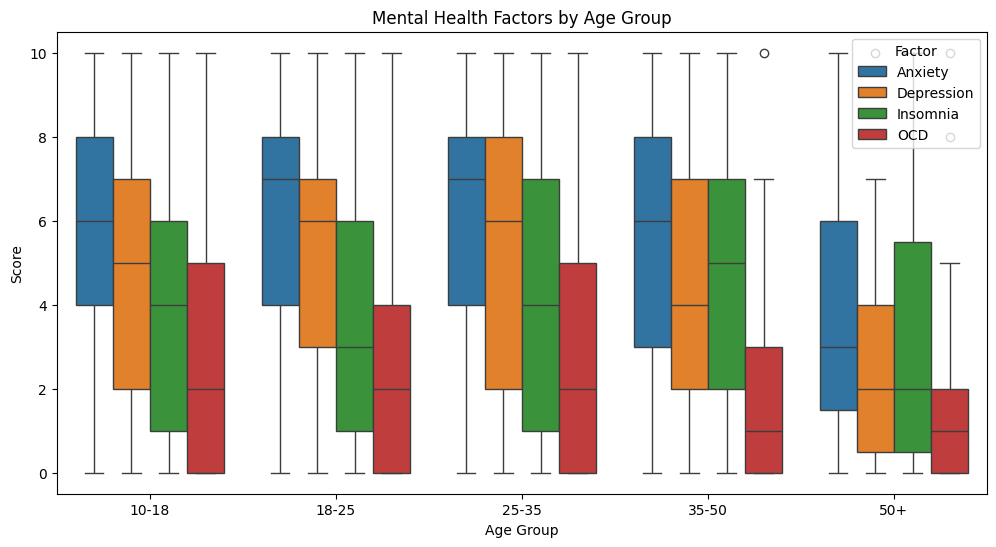

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_long,
    x="Age_group",
    y="Score",
    hue="Mental_health_factor"
)

plt.title("Mental Health Factors by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Score")

plt.legend(title="Factor")
plt.show()

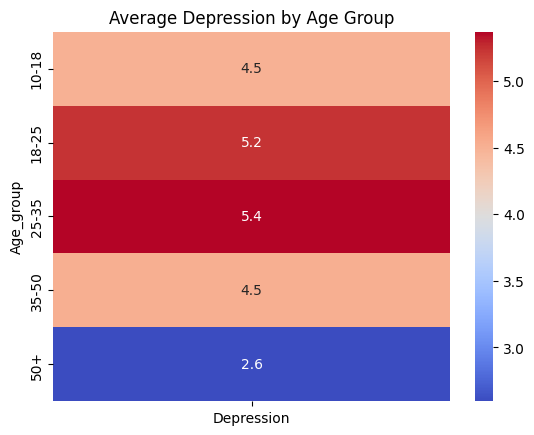

In [ ]:
pivot = df.pivot_table(values="Depression",
                       index="Age_group",
                       aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Average Depression by Age Group")
plt.show()

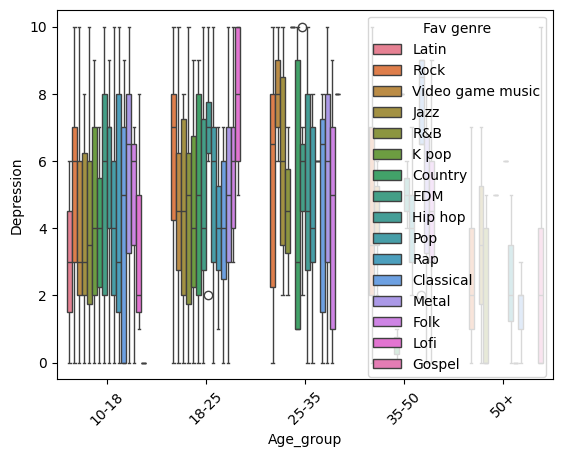

In [ ]:
sns.boxplot(x="Age_group", y="Depression", hue="Fav genre", data=df)
plt.xticks(rotation=45)
plt.show()

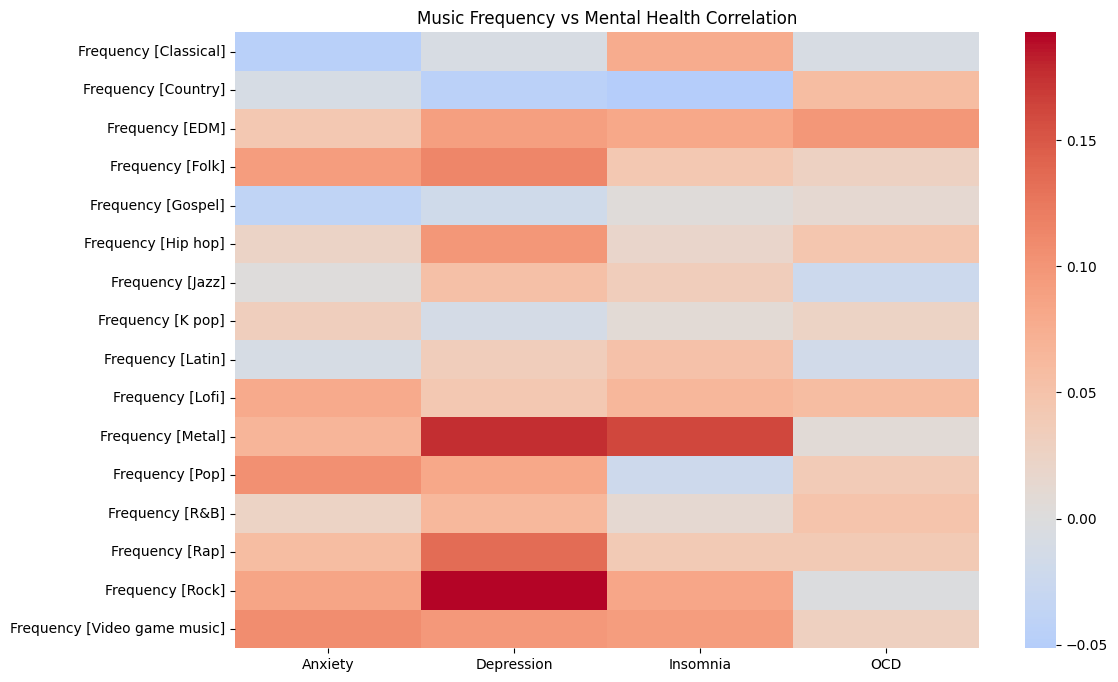

In [ ]:
music_cols = [col for col in df.columns if "Frequency" in col]
mental = ["Anxiety", "Depression", "Insomnia", "OCD"]

corr = df[music_cols + mental].corr()


plt.figure(figsize=(12, 8))
sns.heatmap(
    corr.loc[music_cols, mental],
    cmap="coolwarm",
    center=0
)

plt.title("Music Frequency vs Mental Health Correlation")
plt.show()

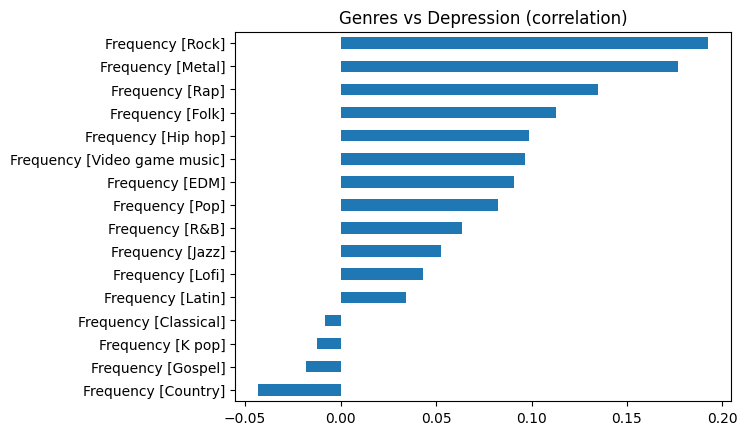

In [ ]:
corr_music_mental = df[music_cols + mental].corr().loc[music_cols, mental]

corr_music_mental["Depression"].sort_values().plot(kind="barh")

plt.title("Genres vs Depression (correlation)")
plt.show()

In [ ]:
df["Rock_high"] = df["Frequency [Rock]"] >= 2

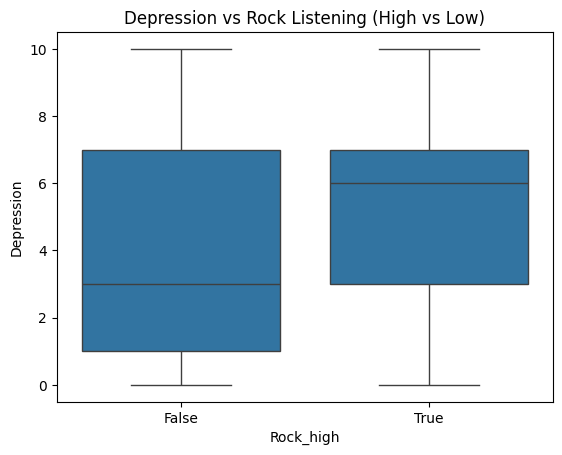

In [ ]:
sns.boxplot(x="Rock_high", y="Depression", data=df)
plt.title("Depression vs Rock Listening (High vs Low)")
plt.show()

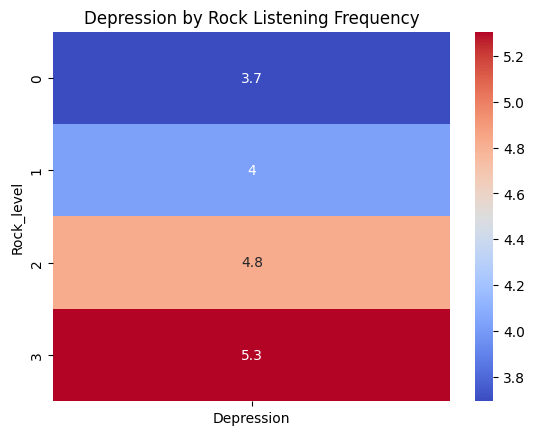

In [ ]:
df["Rock_level"] = df["Frequency [Rock]"]

pivot = df.pivot_table(
    values="Depression",
    index="Rock_level",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Depression by Rock Listening Frequency")
plt.show()

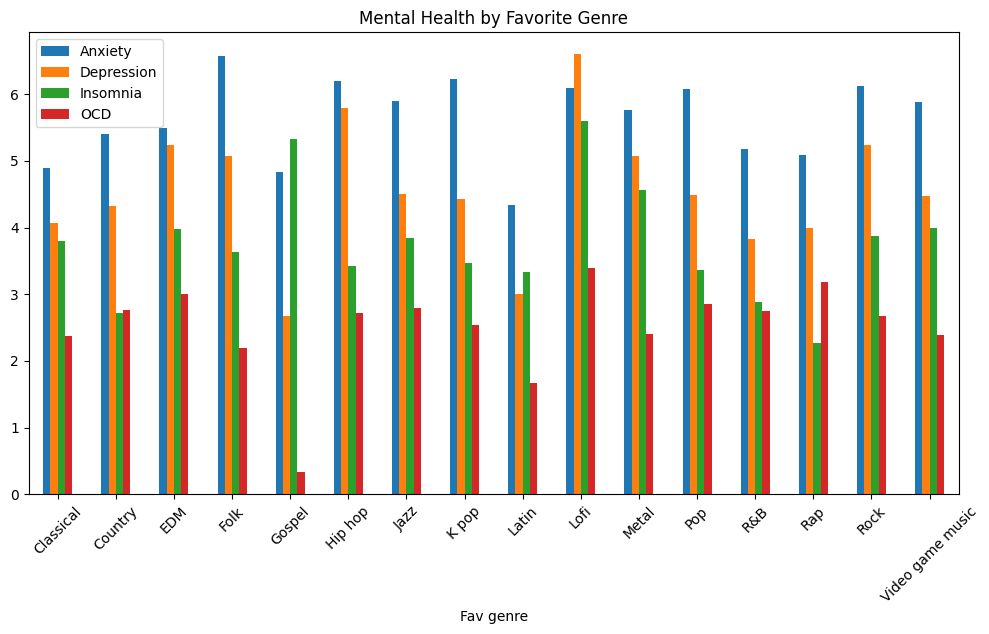

In [ ]:
df.groupby("Fav genre")[mental].mean().plot(kind="bar", figsize=(12,6))

plt.title("Mental Health by Favorite Genre")
plt.xticks(rotation=45)
plt.show()

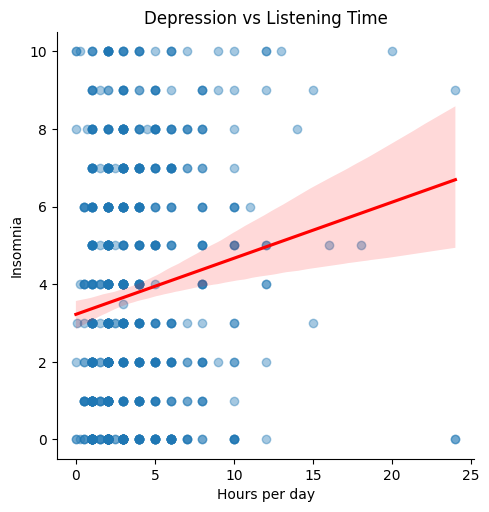

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    x="Hours per day",
    y="Insomnia",
    data=df,
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Depression vs Listening Time")
plt.show()

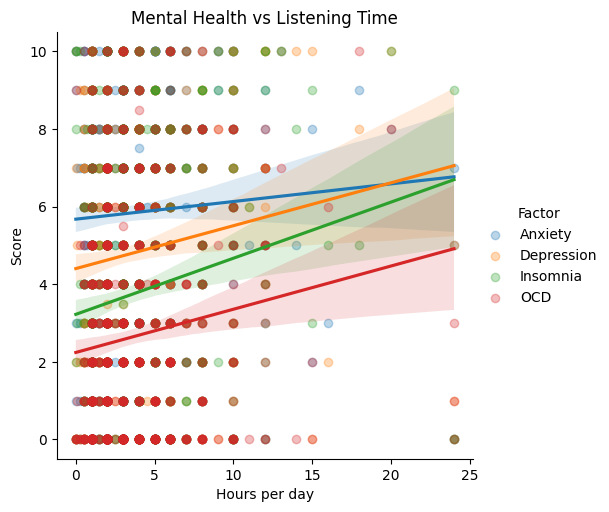

In [ ]:
mental = ["Anxiety", "Depression", "Insomnia", "OCD"]

df_long = df.melt(
    id_vars=["Hours per day"],
    value_vars=mental,
    var_name="Factor",
    value_name="Score"
)

sns.lmplot(
    x="Hours per day",
    y="Score",
    hue="Factor",
    data=df_long,
    scatter_kws={"alpha":0.3}
)

plt.title("Mental Health vs Listening Time")
plt.show()

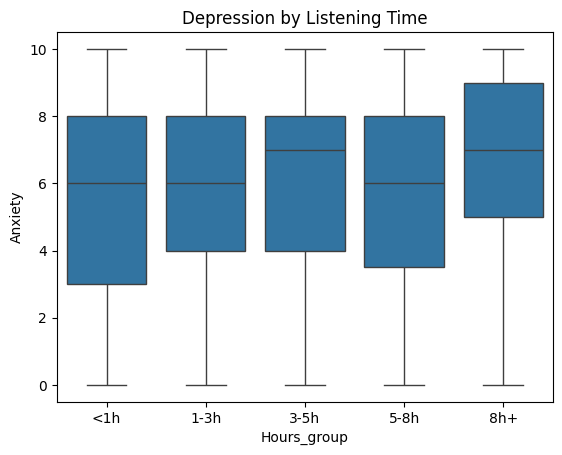

In [ ]:
import pandas as pd

df["Hours_group"] = pd.cut(
    df["Hours per day"],
    bins=[0, 1, 3, 5, 8, 24],
    labels=["<1h", "1-3h", "3-5h", "5-8h", "8h+"]
)

sns.boxplot(
    x="Hours_group",
    y="Anxiety",
    data=df
)

plt.title("Depression by Listening Time")
plt.show()

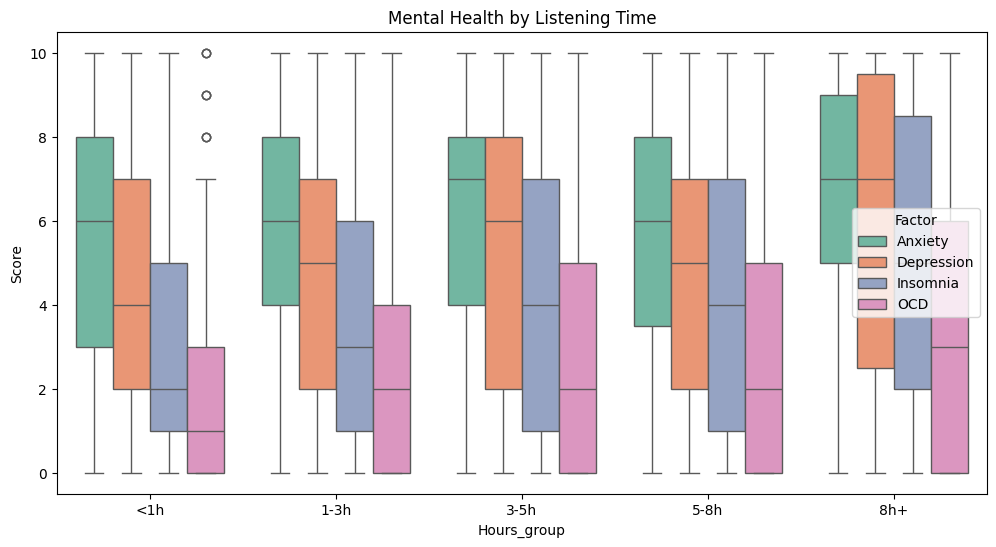

In [ ]:
df_long = df.melt(
    id_vars=["Hours_group"],
    value_vars=mental,
    var_name="Factor",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_long,
    x="Hours_group",
    y="Score",
    hue="Factor",
    palette="Set2"
)

plt.title("Mental Health by Listening Time")
plt.show()

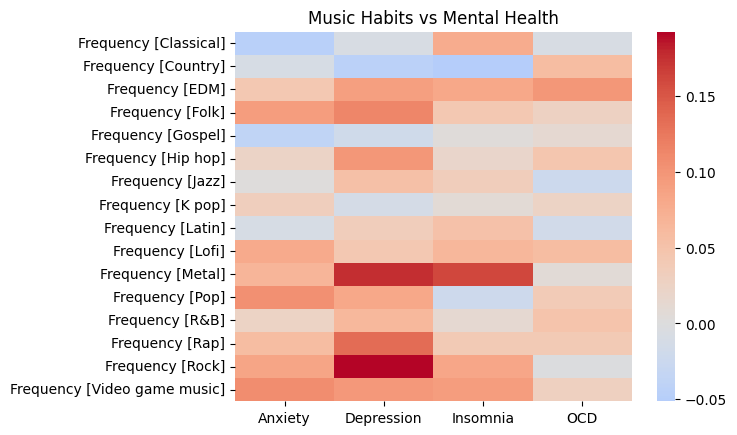

In [ ]:
sns.heatmap(
    corr.loc[music_cols, mental],
    cmap="coolwarm",
    center=0
)

plt.title("Music Habits vs Mental Health")
plt.show()

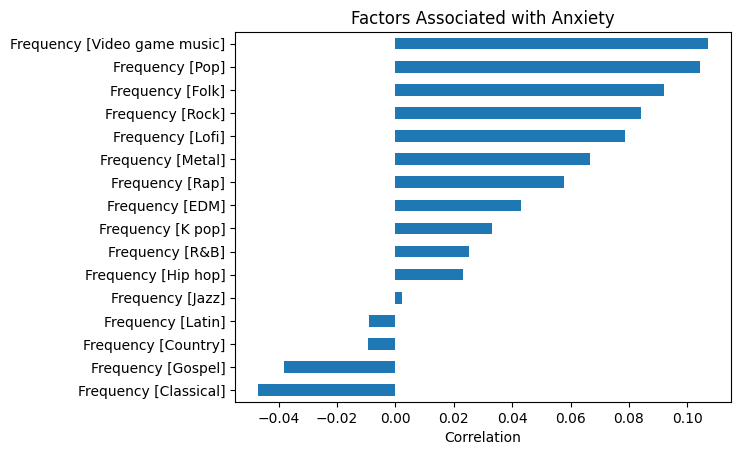

In [ ]:
music_cols = [col for col in df.columns if "Frequency" in col]
mental = ["Anxiety", "Depression", "Insomnia", "OCD"]

corr = df[music_cols + mental].corr()

corr["Anxiety"].loc[music_cols].sort_values().plot(kind="barh")

plt.title("Factors Associated with Anxiety")
plt.xlabel("Correlation")
plt.show()

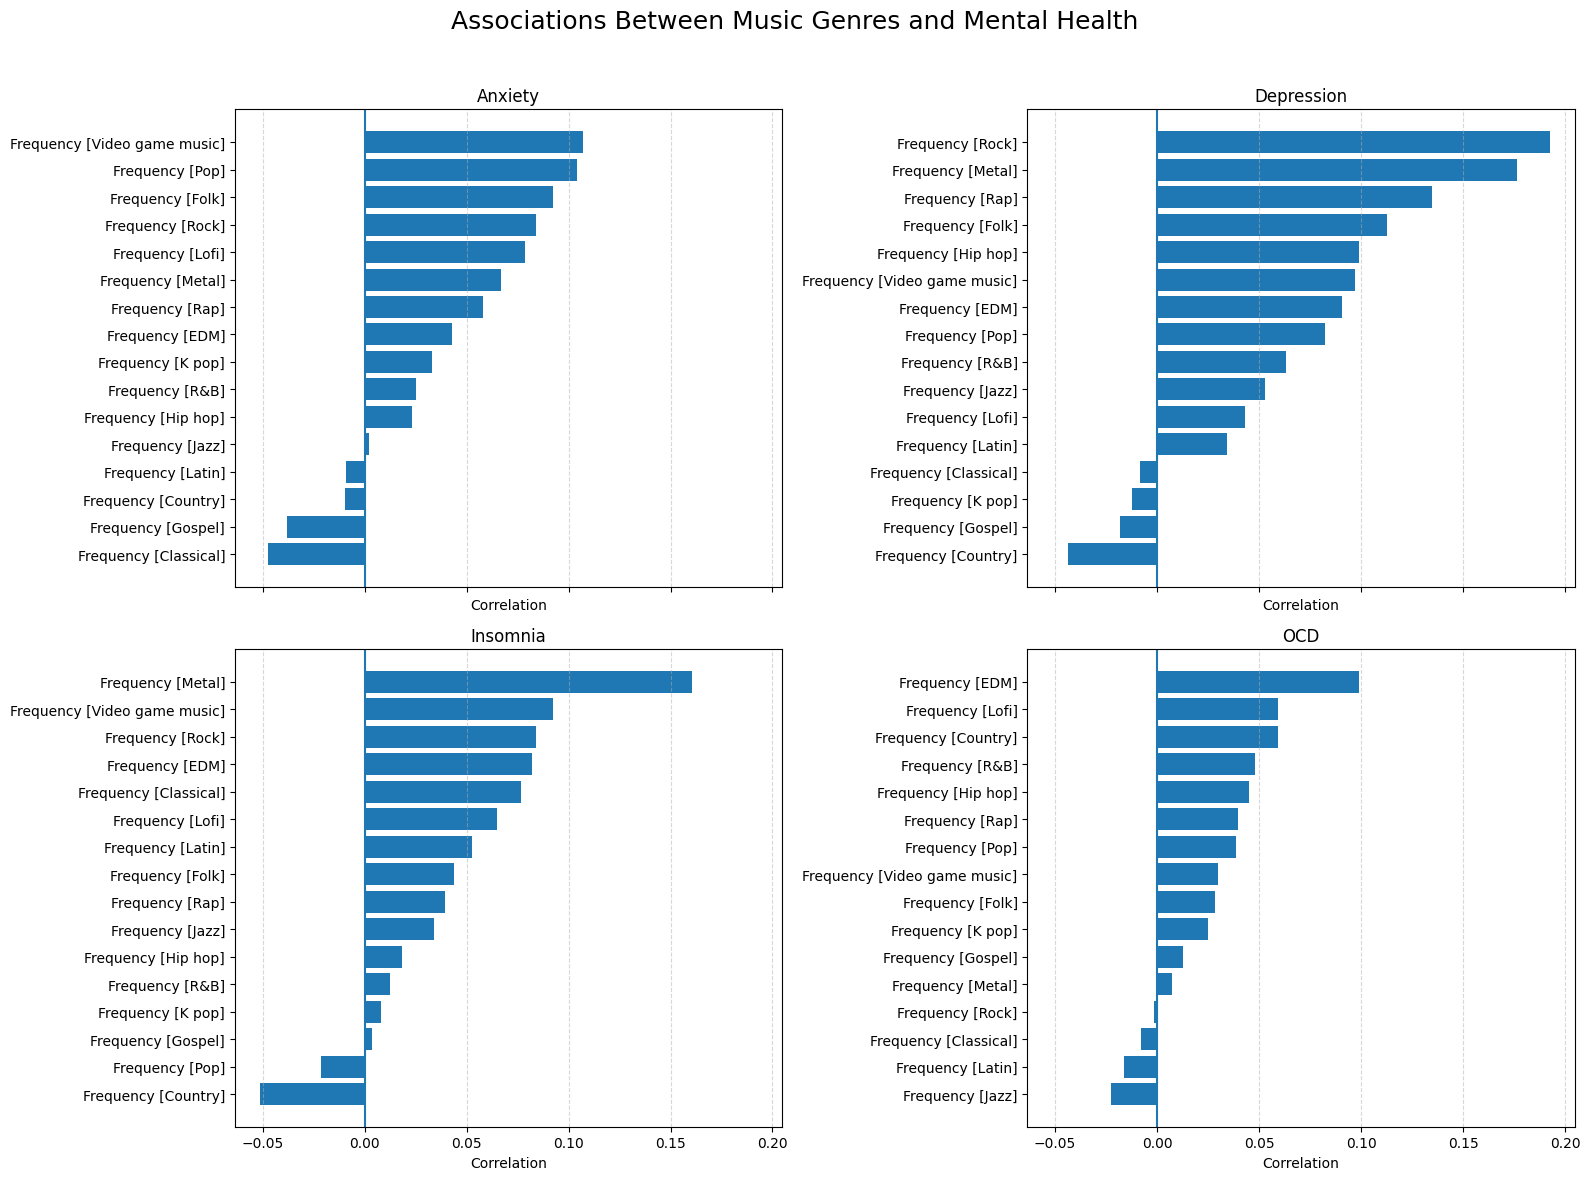

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, m in enumerate(mental):
    data = corr[m].loc[music_cols].sort_values()
    
    axes[i].barh(data.index, data.values)
    axes[i].set_title(m)
    axes[i].set_xlabel("Correlation")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
    axes[i].axvline(0)

plt.suptitle("Associations Between Music Genres and Mental Health", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()